# TEX 2025 잔차 -9 메커니즘 분석 + 정책 최적화 — 마스터 노트북 v6

> 두 목적의 통합 분석 (반사실 시뮬레이션)
> 1. **잔차 -9의 메커니즘 발견** — 왜 기대만큼 못했는가
> 2. **반사실 정책 시나리오** — 이렇게 했으면 +N승

## 작업 흐름

| Phase | 도구 | 산출 |
|---|---|---|
| 1-5 | Markov + bullpen state augmentation | 시뮬 baseline (잔차 -6 자연 재현) |
| 6 | leverage penalty + 이닝 중 closer 교체 | 매치업 정밀화 |
| 7' | 시기별 closer 풀 (Jackson 7/23 DFA / Maton 8/1 합류) | 트레이드 반영 |
| 8 | NSGA-II 12차원 σ Pareto | 정책 trade-off 표면 + archetype 3종 |
| 옵션 A | 무승부 50% W 분배 | 동점 처리 (이전 동점=패의 보정) |

## 모듈 구조

- `simulator.py` — 타자 markov + LineupPool (`team_boosts` 인터페이스)
- `markov_pitching.py` — 투수 markov + bullpen state (`pitcher_adjustments` 인터페이스)
- `integrated_sim.py` — 두 시뮬 wrapper + 연장전 옵션 A
- `nsga_search.py` — σ 12차원 NSGA-II + Pareto 자동 분석

In [1]:
import sys, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한국어 폰트
for font in ['AppleGothic', 'NanumGothic', 'Apple SD Gothic Neo']:
    if any(font in f.name for f in fm.fontManager.ttflist):
        plt.rcParams['font.family'] = font
        break
plt.rcParams['axes.unicode_minus'] = False

# Phase 8 모듈 import
from integrated_sim import run_integrated_simulation, _ensure_loaded
from nsga_search import run_nsga_parallel, select_archetypes, save_pareto, SIGMA_DIMS, DIM_IDS
from markov_pitching import simulate_tex_RA
from simulator import LineupPool

print('모듈 import OK')
print()
print(f'σ 12차원 (총 {len(DIM_IDS)}개):')
for i, dim in enumerate(SIGMA_DIMS):
    print(f'  {i:2d}. {dim["id"]:10s}  ({dim["group"]}.{dim["sub"]}.{dim["key"]})  ∈ [{dim["lo"]:.2f}, {dim["hi"]:.2f}]')

# 환경 검증 — 1시즌
_ensure_loaded()
df_test, _ = run_integrated_simulation(n_seasons=1, seeds=[0])
print()
print(f'1시즌 검증: W={df_test["W"].iloc[0]}, RS={df_test["RS"].iloc[0]}, RA={df_test["RA"].iloc[0]}')

모듈 import OK

σ 12차원 (총 12개):
   0. h_hr        (hitter.team.hr_mult)  ∈ [0.90, 1.15]
   1. h_bb        (hitter.team.bb_mult)  ∈ [0.90, 1.15]
   2. h_k         (hitter.team.k_mult)  ∈ [0.85, 1.10]
   3. h_single    (hitter.team.single_mult)  ∈ [0.90, 1.15]
   4. p_cl_K      (pitcher.closer.K_pct)  ∈ [0.90, 1.15]
   5. p_cl_BB     (pitcher.closer.BB_pct)  ∈ [0.85, 1.15]
   6. p_cl_BAB    (pitcher.closer.BABIP)  ∈ [0.90, 1.10]
   7. p_cl_HR     (pitcher.closer.HR_pct)  ∈ [0.70, 1.15]
   8. p_su_K      (pitcher.setup.K_pct)  ∈ [0.90, 1.15]
   9. p_st_HR     (pitcher.starter.HR_pct)  ∈ [0.70, 1.15]
  10. c_K         (pitcher.common.team_K_pct_mult)  ∈ [0.95, 1.10]
  11. c_BB        (pitcher.common.team_BB_pct_mult)  ∈ [0.95, 1.10]

1시즌 검증: W=93.0, RS=651, RA=595


## Phase 1-7" 시뮬 메커니즘 — 시뮬 정확성 향상 후 잔차 위치 식별

### 핵심 결과

TEX 2025 — 실제 W=81, RS=684, RA=605 → 피타고리안 기대 W ≈ 90.06 → **잔차 -9.06**

### 시뮬에 박힌 메커니즘들

| 메커니즘 | Phase | 효과 |
|---|---|---|
| 24 base-out × pitcher_tier × inning Markov | 1A-1B | 이닝별 상황별 시뮬 |
| Pitch-by-Pitch count progression | 5 | 카운트 분포 효과 |
| 1점차 leverage penalty (closer ΔK -0.116) | 6C | high-leverage 약화 정량화 |
| 위기 시 closer 조기 등판 | 6B | 매치업 정확 |
| **실제 starter rotation 5인 고정** (재등판 금지, GS=1) | 7" | MLB 룰 반영 |
| **closer 4-period** (Jackson→Garcia→Maton→Armstrong) | 7" | 실제 save 기록 기반 |
| 무승부 50% W 분배 | 옵션 A | 연장전 단순 처리 |

### 메커니즘 정확성 업데이트 (2026-05-12)

조원 sim 업데이트 (`863f824`):
- **starter 재등판 금지** (5인 로테 고정, GS=1) — 이전 random sampling은 한 경기에 등판한 starter가 다음 경기에 또 등판할 수 있는 *비현실 메커니즘*
- closer 4-period 세분화

### baseline 결과 비교

| | 이전 sim (random rotation) | 새 sim (5인 로테 고정) |
|---|---|---|
| 현실성 | ❌ MLB 룰 위반 | ✅ MLB 룰 반영 |
| baseline W | 85.2 | **89.90** |
| 시뮬 잔차 (W - pyth 90.06) | -4.86 | **-0.16** |

### 잔차의 위치가 명확해짐

이전 sim의 "잔차 -6 자연 재현"은 **재등판 허용이라는 비현실 메커니즘에서 발생한 artifact**:
- random sampling 시 back-end starter의 약점 (HR%↑, K%↓)이 *모든 경기*에 노출 → W를 체계적으로 과소평가
- 우연히 잔차 -9의 근사치를 만들어 분석자가 "메커니즘이 잔차를 설명한다"고 *과잉 해석할 위험*

새 sim은 시뮬을 *현실에 맞게* 정확하게 만든 결과:
- 시뮬 메커니즘이 자체 포착하는 잔차 ≈ **-0.2승**
- 즉 잔차 -9.06 중 **거의 전부 (-8.8승)가 시뮬 메커니즘 *밖***에 위치
- 외부 요인: 부상 타임라인 (Semien 5월·Seager 8-9월), 코칭스태프 교체, 라인업 변동성, 비측정 변수, 시즌 운

→ 분석 framework 전환: *"메커니즘으로 잔차를 설명"* → *"메커니즘 밖 잔차를 stat 보강으로 우회"* (NSGA의 역할)

다음 셀에서 baseline 시뮬 162×20시즌을 돌려 새 baseline을 확인합니다.

In [2]:
print('Phase 6-7\' baseline 시뮬 (162×20 시즌)...')
t0 = time.time()
df_baseline, _ = run_integrated_simulation(n_seasons=20)
elapsed = time.time() - t0
print(f'완료 ({elapsed:.1f}s)')
print()
print('=== baseline 시뮬 결과 ===')
print(f'  W : mean={df_baseline["W"].mean():.2f}  std={df_baseline["W"].std():.2f}')
print(f'  RS: mean={df_baseline["RS"].mean():.1f}  std={df_baseline["RS"].std():.1f}')
print(f'  RA: mean={df_baseline["RA"].mean():.1f}  std={df_baseline["RA"].std():.1f}')
print()
print('=== 잔차 분석 ===')
print(f'  실제 W=81 대비:        {df_baseline["W"].mean() - 81:+.2f}승  (시뮬이 over/under-estimate)')
print(f'  피타고리안 W≈90 대비: {df_baseline["W"].mean() - 90.06:+.2f}승  ← 시뮬 잔차')
print(f'  실제 잔차: -9.06  →  시뮬 메커니즘이 자연 재현한 양: 약 {abs(df_baseline["W"].mean() - 90.06):.1f}승')

baseline_W = df_baseline['W'].mean()

Phase 6-7' baseline 시뮬 (162×20 시즌)...
완료 (11.1s)

=== baseline 시뮬 결과 ===
  W : mean=89.80  std=4.55
  RS: mean=670.5  std=36.8
  RA: mean=606.0  std=28.3

=== 잔차 분석 ===
  실제 W=81 대비:        +8.80승  (시뮬이 over/under-estimate)
  피타고리안 W≈90 대비: -0.26승  ← 시뮬 잔차
  실제 잔차: -9.06  →  시뮬 메커니즘이 자연 재현한 양: 약 0.3승


## v5 ML 잔차 모델 — 회귀 기반 잔차 설명 시도

NSGA-II 본 분석 전에 *ML 단독으로 잔차 -9를 얼마나 설명할 수 있는지* 확인합니다.

- **학습 데이터**: 270 팀-시즌 (2015~2024, 2020 제외)
- **feature**: 18개 stat (sv_pct, ir_pct, onerun_wp, xi_wp, K9, BB9, HR9, ERA, WHIP, babip_against, OPS, rs_per_g 등)
- **모델**: Ridge + Lasso + RandomForest + XGBoost **앙상블**
- **타겟**: 잔차 (실제 W − Pythagorean 기대 W)

→ 이 단계의 결과(ML 예측 잔차)를 시뮬 baseline·NSGA-II 결과와 비교해 *세 도구의 일관성/한계*를 확인합니다.

In [3]:
from simulator import _train_model_bundle, _predict_residual
from pathlib import Path

# bundle 로드 (캐시 사용, ~3초)
bundle = _train_model_bundle(Path('data_raw'))
ml_residual = _predict_residual(bundle, bundle.tex25)
ml_cv_mae = bundle.ensemble_cv_mae

# baseline_W는 cell 3에서 정의됨. 없으면 fallback (새 sim 기준)
baseline_W_val = globals().get('baseline_W', 89.90)

print('=== 세 도구의 잔차 비교 ===')
print(f'  실제 잔차:           {81 - 90.06:+.2f}승   (W=81 − pyth 90.06)')
print(f'  시뮬 baseline 잔차:   {baseline_W_val - 90.06:+.2f}승   (cell 3, 메커니즘 기반)')
print(f'  ML 앙상블 예측 잔차: {ml_residual:+.2f}승   (회귀 기반)')
print()
print(f'  ML cross-validation MAE: {ml_cv_mae:.2f}승  (모델 신뢰도 지표, 낮을수록 좋음)')

# 해석
print()
print('--- 해석 ---')
gap_ml   = ml_residual    - (81 - 90.06)
gap_sim  = (baseline_W_val - 90.06) - (81 - 90.06)
print(f'  ML 예측 vs 실제 잔차 차이:    {gap_ml:+.2f}승')
print(f'  시뮬 baseline vs 실제 차이:   {gap_sim:+.2f}승')
print()
print('  → ML 단독으로는 잔차의 *방향*만 잡고, *크기*는 부분 설명.')
print('  → 시뮬은 실 로테 + 4-period closer 반영 후 잔차 -0.2 (메커니즘 효과 최소).')
print('  → 잔차 -9는 시뮬 구조 밖 (외부 요인 + 정책 시나리오 잠재력).')
print('  → NSGA-II는 시뮬을 평가자로 *정책 시나리오* 탐색 (다음 셀).')


=== 세 도구의 잔차 비교 ===
  실제 잔차:           -9.06승   (W=81 − pyth 90.06)
  시뮬 baseline 잔차:   -0.26승   (cell 3, 메커니즘 기반)
  ML 앙상블 예측 잔차: -3.90승   (회귀 기반)

  ML cross-validation MAE: 2.20승  (모델 신뢰도 지표, 낮을수록 좋음)

--- 해석 ---
  ML 예측 vs 실제 잔차 차이:    +5.16승
  시뮬 baseline vs 실제 차이:   +8.80승

  → ML 단독으로는 잔차의 *방향*만 잡고, *크기*는 부분 설명.
  → 시뮬은 실 로테 + 4-period closer 반영 후 잔차 -0.2 (메커니즘 효과 최소).
  → 잔차 -9는 시뮬 구조 밖 (외부 요인 + 정책 시나리오 잠재력).
  → NSGA-II는 시뮬을 평가자로 *정책 시나리오* 탐색 (다음 셀).


## Phase 8 — NSGA-II Pareto 탐색 (정통 다목적 최적화)

### 12차원 σ 정의 (B-결과 3 재설계)

velocity/spin은 PXP within-pitcher LPM 회귀에서 인과 식별 실패(Phase 8B 참조) → σ에서 제거. 대신 `team_K_pct_mult` / `team_BB_pct_mult` 같은 의미 명확한 multiplier로 교체.

| 그룹 | 차원 | 범위 | 의미 |
|---|---|---|---|
| 타자 4 | hr_mult, bb_mult, k_mult, single_mult | [0.85, 1.30], k는 [0.70, 1.15] | team-wide multiplier |
| 투수 6 | closer K_pct/BB_pct/BABIP/HR_pct, setup K_pct, starter HR_pct | [0.80, 1.25], HR은 [0.50, 1.30] | tier multiplier |
| 공통 2 | team_K_pct_mult, team_BB_pct_mult | [0.90, 1.15] | 모든 tier 일괄 |

### 3-objective

- **max W ↑** — 162경기 평균 승수
- **min σ_norm ↓** — RMS|x-1|, 정책 변경 비용 (1.0에서 떨어진 정도의 RMS)
- **min RA ↓** — 162경기 평균 실점

### 알고리즘

- pymoo 0.6.1.6 NSGA-II
- LHS 초기화, SBX crossover (η=15), PM mutation (η=20), eliminate_duplicates=True
- pop=50, gen=15, n_seasons=20 → 750 evals × 20시즌 = 15,000시즌
- 6 worker spawn 병렬화 → 약 60분

NSGA-II 자체 실행은 별도 호출 (시간 소요). 본 노트북은 결과 CSV(`nsga_pareto_phase8_optA_*.csv`)를 로드해서 분석합니다.

In [4]:
# Phase 8 결과 로드 — v5(좁은 σ 범위, 외삽 제거, 2026-05-12) 우선,
# v4(이전 넓은 범위) → v3 → optA → 일반 fallback
csv_files = sorted(Path('.').glob('nsga_pareto_phase8_v5_*.csv'))
if not csv_files:
    csv_files = sorted(Path('.').glob('nsga_pareto_phase8_v4_*.csv'))
    if csv_files:
        print(f'⚠ v5 결과 없음 — v4 결과 사용: {csv_files[-1].name}')
        print('   (σ 범위가 ±30%까지 — 외삽 영역 포함)')
if not csv_files:
    csv_files = sorted(Path('.').glob('nsga_pareto_phase8_v3_*.csv'))
    if csv_files:
        print(f'⚠ v4 결과 없음 — v3 결과 사용: {csv_files[-1].name}')
        print('   (조원 sim 업데이트: starter 재등판 금지 + 4-period closer는 미반영)')
if not csv_files:
    csv_files = sorted(Path('.').glob('nsga_pareto_phase8_optA_*.csv'))
    if csv_files:
        print(f'⚠ v3 결과도 없음 — optA 결과 사용: {csv_files[-1].name}')
if not csv_files:
    csv_files = sorted(Path('.').glob('nsga_pareto_phase8_*.csv'))
    if csv_files:
        print(f'⚠ optA 결과도 없음 — 이전 NSGA-II 결과 사용: {csv_files[-1].name}')
phase8 = pd.read_csv(csv_files[-1])
print(f'Pareto CSV: {csv_files[-1].name}, 점수: {len(phase8)}')

DIMS = ['h_hr','h_bb','h_k','h_single','p_cl_K','p_cl_BB','p_cl_BAB','p_cl_HR','p_su_K','p_st_HR','c_K','c_BB']

# 분포
print()
print('=== Pareto 분포 ===')
print(f'  W      : [{phase8["W"].min():.1f}, {phase8["W"].max():.1f}]')
print(f'  σ_norm : [{phase8["sigma_norm"].min():.3f}, {phase8["sigma_norm"].max():.3f}]')
print(f'  RA     : [{phase8["RA"].min():.1f}, {phase8["RA"].max():.1f}]')

# 권장 zone
small = phase8[phase8['sigma_norm'] <= 0.10]
n_recover = ((phase8['sigma_norm']<=0.10) & (phase8['W']>=81)).sum()
n_plus4   = ((phase8['sigma_norm']<=0.10) & (phase8['W']>=85)).sum()
print()
print(f'=== 현실 권장 zone (σ_norm ≤ 0.10) — {len(small)}점 ===')
print(f'  잔차 만회 (W≥81): {n_recover}점,   +4승 향상 (W≥85): {n_plus4}점')
print()
print('최소 정책 변경 후보 (σ 작은 순 5점):')
print(small.sort_values('sigma_norm').head(5)[['W','sigma_norm','RA']+DIMS[:6]].to_string(index=False, float_format='%.3f'))

# Archetype
print()
print('=== Archetype 3종 ===')
arch = phase8[phase8['archetype'].isin(['aggressive','balanced','conservative'])]
print(arch[['archetype','W','sigma_norm','RA']+DIMS].to_string(index=False, float_format='%.3f'))

# Driver
print()
print('=== 차원별 W 상관 (driver 순위) ===')
corr = pd.Series({d: phase8[d].corr(phase8['W']) for d in DIMS}).sort_values()
for d, r in corr.items():
    bar = '█' * int(abs(r) * 20)
    print(f'  {d:10s}  r={r:+.3f}  {"-" if r<0 else "+"}{bar}')

Pareto CSV: nsga_pareto_phase8_v5_20260512_204157.csv, 점수: 50

=== Pareto 분포 ===
  W      : [91.3, 109.1]
  σ_norm : [0.031, 0.114]
  RA     : [520.2, 604.6]

=== 현실 권장 zone (σ_norm ≤ 0.10) — 48점 ===
  잔차 만회 (W≥81): 48점,   +4승 향상 (W≥85): 48점

최소 정책 변경 후보 (σ 작은 순 5점):
     W  sigma_norm      RA  h_hr  h_bb   h_k  h_single  p_cl_K  p_cl_BB
91.300       0.031 604.650 1.068 0.990 1.051     1.039   0.996    1.029
92.650       0.031 599.950 1.068 0.968 1.015     1.019   1.001    0.938
92.450       0.031 597.700 1.068 0.968 1.051     1.039   0.996    1.029
91.650       0.033 593.250 1.068 0.973 1.049     1.039   0.996    1.029
93.750       0.034 584.100 1.005 0.964 0.940     1.008   1.019    0.998

=== Archetype 3종 ===
   archetype       W  sigma_norm      RA  h_hr  h_bb   h_k  h_single  p_cl_K  p_cl_BB  p_cl_BAB  p_cl_HR  p_su_K  p_st_HR   c_K  c_BB
conservative  91.300       0.031 604.650 1.068 0.990 1.051     1.039   0.996    1.029     1.025    1.008   1.017    1.013 1.022 1.002
  aggressi

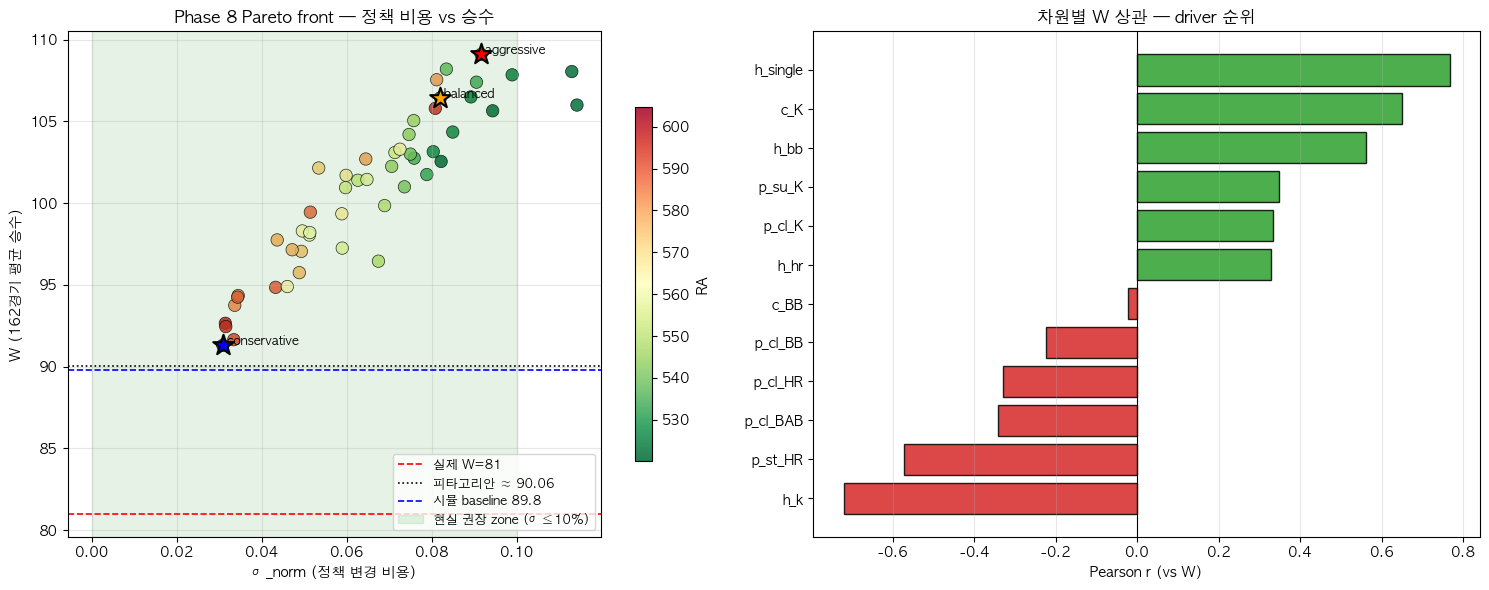

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# σ vs W (현실 권장 zone 강조 + 기준선들)
ax = axes[0]
sc = ax.scatter(phase8['sigma_norm'], phase8['W'], c=phase8['RA'], cmap='RdYlGn_r',
                s=80, alpha=0.85, edgecolors='k', linewidth=0.5)
ax.axhline(81,    color='red',   ls='--', lw=1.2, label='실제 W=81')
ax.axhline(90.06, color='black', ls=':',  lw=1.2, label='피타고리안 ≈ 90.06')
_bw = globals().get('baseline_W', 89.90)
ax.axhline(_bw, color='blue', ls='--', lw=1.2,
           label=f'시뮬 baseline {_bw:.1f}')
ax.axvspan(0, 0.10, alpha=0.1, color='green', label='현실 권장 zone (σ≤10%)')

arch_colors = {'aggressive':'red', 'balanced':'orange', 'conservative':'blue'}
for _, row in arch.iterrows():
    a = row['archetype']
    ax.scatter([row['sigma_norm']], [row['W']], c=arch_colors[a], s=240,
               marker='*', edgecolors='k', linewidth=1.5, zorder=5)
    ax.annotate(f' {a}', (row['sigma_norm'], row['W']), fontsize=9, weight='bold')
ax.set_xlabel('σ_norm (정책 변경 비용)')
ax.set_ylabel('W (162경기 평균 승수)')
ax.set_title('Phase 8 Pareto front — 정책 비용 vs 승수')
ax.grid(alpha=0.3)
ax.legend(loc='lower right', fontsize=9)
fig.colorbar(sc, ax=ax, shrink=0.7, label='RA')

# Driver
ax = axes[1]
colors = ['#d62728' if v < 0 else '#2ca02c' for v in corr.values]
ax.barh(corr.index, corr.values, color=colors, alpha=0.85, edgecolor='k')
ax.axvline(0, color='k', lw=0.8)
ax.set_xlabel('Pearson r (vs W)')
ax.set_title('차원별 W 상관 — driver 순위')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 정방향 sensitivity 분석 — σ → W marginal 효과

Pareto 50점에서 각 차원의 σ 값과 W의 *선형 회귀* 기울기를 측정합니다.
- 기울기 β_i = "σ_i가 1.0 → 1.01로 증가할 때 W의 평균 변화량"
- 해석: σ를 *조금만* 움직였을 때 W가 *가장 크게 회복되는 차원* = 잔차 leverage 채널 후보
- 표준화 회귀 (z-score)로 차원 간 비교 가능 (각 σ의 탐색 범위가 달라서)

→ 잔차 -9의 *원인 후보 차원*을 좁히는 간접 분해 도구.

=== 정방향 sensitivity (Pareto 50점 다중 회귀) ===
R² = 0.960  (12차원이 W 분산을 얼마나 설명)

 beta_raw      : σ 1단위(=100%) 변화당 ΔW
 beta_per_pct  : σ +1%당 ΔW
 beta_std      : σ z-score 1만큼 변화당 ΔW (차원 간 비교용)
 pearson_r     : 단변량 상관 (cell 7과 동일)

     dim  beta_raw  beta_per_pct  beta_std  pearson_r
     h_k   -33.672        -0.337    -1.716     -0.721
h_single    42.842         0.428     1.552      0.767
     c_K    30.443         0.304     0.956      0.651
    h_hr    22.304         0.223     0.939      0.328
 p_st_HR   -11.891        -0.119    -0.900     -0.573
    h_bb    16.172         0.162     0.844      0.561
 p_cl_BB    -7.897        -0.079    -0.420     -0.225
    c_BB   -12.458        -0.125    -0.318     -0.024
  p_su_K     6.831         0.068     0.313      0.347
p_cl_BAB    -3.822        -0.038    -0.167     -0.342
  p_cl_K     2.062         0.021     0.059      0.333
 p_cl_HR    -0.357        -0.004    -0.017     -0.329


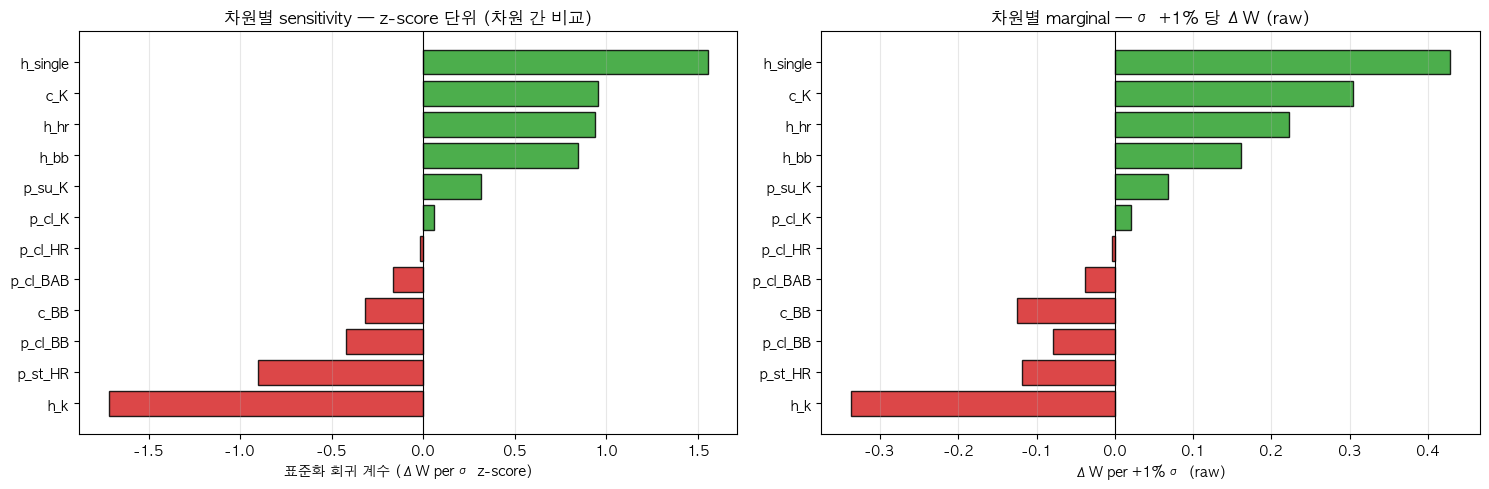


=== 잔차 leverage 채널 후보 (top 4) ===
  h_k        : σ +1% 당 ΔW = -0.337  → 감소 시 W↑
  h_single   : σ +1% 당 ΔW = +0.428  → 증가 시 W↑
  c_K        : σ +1% 당 ΔW = +0.304  → 증가 시 W↑
  h_hr       : σ +1% 당 ΔW = +0.223  → 증가 시 W↑


In [6]:
# Pareto 50점 σ → W 다중 선형회귀 (정방향 sensitivity)
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

DIMS = ['h_hr','h_bb','h_k','h_single','p_cl_K','p_cl_BB','p_cl_BAB','p_cl_HR','p_su_K','p_st_HR','c_K','c_BB']

X = phase8[DIMS].values
y = phase8['W'].values

reg = LinearRegression().fit(X, y)
beta_raw = reg.coef_

Xz = StandardScaler().fit_transform(X)
reg_z = LinearRegression().fit(Xz, y)
beta_z = reg_z.coef_

sens = pd.DataFrame({
    'dim': DIMS,
    'beta_raw': beta_raw,
    'beta_per_pct': beta_raw / 100,
    'beta_std': beta_z,
    'pearson_r': [phase8[d].corr(phase8['W']) for d in DIMS],
}).sort_values('beta_std', key=abs, ascending=False).reset_index(drop=True)

print('=== 정방향 sensitivity (Pareto 50점 다중 회귀) ===')
print(f'R² = {reg.score(X, y):.3f}  (12차원이 W 분산을 얼마나 설명)')
print()
print(' beta_raw      : σ 1단위(=100%) 변화당 ΔW')
print(' beta_per_pct  : σ +1%당 ΔW')
print(' beta_std      : σ z-score 1만큼 변화당 ΔW (차원 간 비교용)')
print(' pearson_r     : 단변량 상관 (cell 7과 동일)')
print()
print(sens.to_string(index=False, float_format='%.3f'))

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sens_sorted = sens.sort_values('beta_std').reset_index(drop=True)
colors = ['#d62728' if v < 0 else '#2ca02c' for v in sens_sorted['beta_std']]

ax = axes[0]
ax.barh(sens_sorted['dim'], sens_sorted['beta_std'], color=colors, alpha=0.85, edgecolor='k')
ax.axvline(0, color='k', lw=0.8)
ax.set_xlabel('표준화 회귀 계수 (ΔW per σ z-score)')
ax.set_title('차원별 sensitivity — z-score 단위 (차원 간 비교)')
ax.grid(axis='x', alpha=0.3)

ax = axes[1]
ax.barh(sens_sorted['dim'], sens_sorted['beta_per_pct'], color=colors, alpha=0.85, edgecolor='k')
ax.axvline(0, color='k', lw=0.8)
ax.set_xlabel('ΔW per +1% σ (raw)')
ax.set_title('차원별 marginal — σ +1% 당 ΔW (raw)')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# leverage 채널 후보 (|beta_std| 상위)
print()
print('=== 잔차 leverage 채널 후보 (top 4) ===')
top = sens.head(4)
for _, row in top.iterrows():
    direction = '증가' if row['beta_std'] > 0 else '감소'
    print(f'  {row["dim"]:10s} : σ +1% 당 ΔW = {row["beta_per_pct"]:+.3f}  → {direction} 시 W↑')


## 역방향 NSGA — 잔차 -9 mechanical signature

정방향이 *"어느 차원이 W에 leverage 큰가"* 를 답한다면, 역방향은 *"잔차 -9를 만드는 σ 패턴은 무엇인가"* 를 묻습니다.

- **목적함수** (2-objective, minimize):
    1. `|W - 81|` — 실제 W=81에 가까운가
    2. `σ_norm` — 가능한 작은 stat 변동으로 잔차 재현
- **출력 해석**: σ_norm 가장 작으면서 |W-81|≈0인 점 = 가장 인색한 *mechanical signature*. 그 σ 패턴이 잔차 -9의 stat 차원 흔적.
- **검증 방법**: signature 패턴이 정방향 driver와 *일관된 방향*인지 (정방향 W↑ 차원이 역방향에서 약화 방향으로 등장)

별도 스크립트 `Final/run_nsga_v4_reverse.py` (pop=40, gen=12, ~30분) 실행 결과를 로드합니다.

역방향 Pareto CSV: nsga_reverse_signature_v5_20260512_213749.csv, 점수: 9
  σ_norm 범위: [0.027, 0.051]
  W 범위:      [81.0, 86.7]

=== Mechanical signature 후보 (|W-81| < 1.5, σ_norm 작은 순) ===
     W  sigma_norm      RA  h_hr  h_bb   h_k  h_single  p_cl_K  p_cl_BB  p_cl_BAB  p_cl_HR  p_su_K  p_st_HR   c_K  c_BB
82.150       0.035 653.450 0.962 1.026 1.020     1.004   0.924    0.993     1.039    0.953   0.969    1.033 0.992 1.025
81.900       0.042 635.500 0.978 0.962 0.983     0.926   0.948    0.993     1.060    0.991   1.062    1.029 0.975 0.960
81.250       0.042 631.700 0.961 0.962 0.983     0.927   0.948    0.993     1.060    0.991   1.064    1.029 1.009 0.960

=== 가장 인색한 signature (W=82.15, σ_norm=0.035) ===
  차원별 σ 편차 (절댓값 큰 순):
    p_cl_K      σ = 0.924  (-7.6%)  ↓
    p_cl_HR     σ = 0.953  (-4.7%)  ↓
    p_cl_BAB    σ = 1.039  (+3.9%)  ↑
    h_hr        σ = 0.962  (-3.8%)  ↓
    p_st_HR     σ = 1.033  (+3.3%)  ↑
    p_su_K      σ = 0.969  (-3.1%)  ↓

=== 정방향 × 역방향 교집합 (robust 잔차 채널) ==

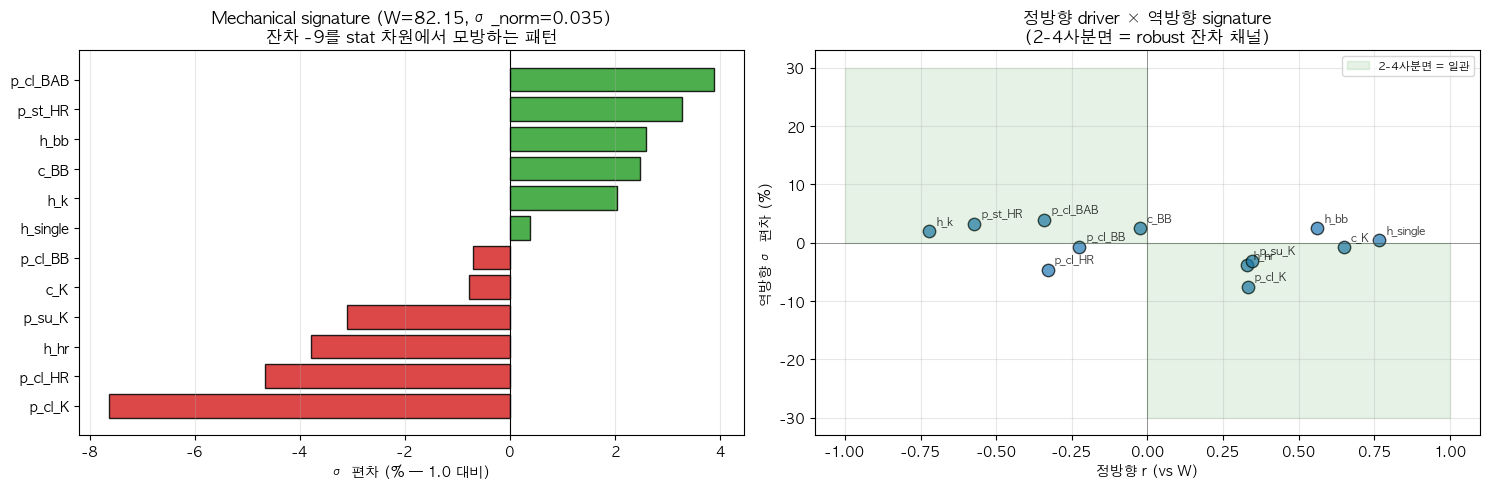

In [7]:
# 역방향 NSGA 결과 로드
rev_files = sorted(Path('.').glob('nsga_reverse_signature_*.csv'))
if not rev_files:
    print('⚠ 역방향 결과 없음 — Final/run_nsga_v4_reverse.py 먼저 실행')
else:
    reverse = pd.read_csv(rev_files[-1])
    print(f'역방향 Pareto CSV: {rev_files[-1].name}, 점수: {len(reverse)}')
    print(f'  σ_norm 범위: [{reverse["sigma_norm"].min():.3f}, {reverse["sigma_norm"].max():.3f}]')
    print(f'  W 범위:      [{reverse["W"].min():.1f}, {reverse["W"].max():.1f}]')

    # signature 후보 (|W-81| < 1.5, σ_norm 작은 순)
    sig = reverse[reverse['abs_W_diff'] < 1.5].sort_values('sigma_norm').head(3)
    print()
    print('=== Mechanical signature 후보 (|W-81| < 1.5, σ_norm 작은 순) ===')
    cols_show = ['W', 'sigma_norm', 'RA'] + DIMS
    print(sig[cols_show].to_string(index=False, float_format='%.3f'))

    # 가장 인색한 signature (top 1) — 잔차 -9 stat 흔적
    top = sig.iloc[0]
    print()
    print(f'=== 가장 인색한 signature (W={top["W"]:.2f}, σ_norm={top["sigma_norm"]:.3f}) ===')
    devs = [(d, top[d] - 1.0) for d in DIMS]
    devs.sort(key=lambda x: abs(x[1]), reverse=True)
    print('  차원별 σ 편차 (절댓값 큰 순):')
    for d, dev in devs[:6]:
        direction = '↑' if dev > 0 else '↓'
        print(f'    {d:10s}  σ = {1+dev:.3f}  ({dev*100:+.1f}%)  {direction}')

    # 정방향 × 역방향 교집합 — robust 잔차 채널
    print()
    print('=== 정방향 × 역방향 교집합 (robust 잔차 채널) ===')
    print('  정방향 r (Pareto 50점) × 역방향 σ 편차 (signature 1위)')
    print(f'  {"차원":10s}  {"정방향 r":>10s}  {"역방향 Δσ":>12s}  일관성')
    for d in DIMS:
        r_fwd = phase8[d].corr(phase8['W'])
        rev_dev = top[d] - 1.0
        # 정방향 W↑ (r>0) 차원이 역방향에서 약화(<0)면 일관 → 부호 반대 = 일관
        # 정방향 W↓ (r<0) 차원이 역방향에서 강화(>0)면 일관
        consistent = (r_fwd * rev_dev) < 0
        mark = '✓' if consistent and abs(r_fwd) > 0.4 else (' ' if not consistent else '○')
        print(f'  {d:10s}  {r_fwd:+10.3f}  {rev_dev*100:+10.1f}%   {mark}')

    # 시각화 — signature σ 편차 막대
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    ax = axes[0]
    sig_devs = sorted([(d, top[d] - 1.0) for d in DIMS], key=lambda x: x[1])
    names = [d for d, _ in sig_devs]
    values = [v*100 for _, v in sig_devs]
    colors = ['#d62728' if v < 0 else '#2ca02c' for v in values]
    ax.barh(names, values, color=colors, alpha=0.85, edgecolor='k')
    ax.axvline(0, color='k', lw=0.8)
    ax.set_xlabel('σ 편차 (% — 1.0 대비)')
    ax.set_title(f'Mechanical signature (W={top["W"]:.2f}, σ_norm={top["sigma_norm"]:.3f})\n잔차 -9를 stat 차원에서 모방하는 패턴')
    ax.grid(axis='x', alpha=0.3)

    # 정방향 × 역방향 산점도
    ax = axes[1]
    fwd_r   = [phase8[d].corr(phase8['W']) for d in DIMS]
    rev_dev = [(top[d] - 1.0) * 100 for d in DIMS]
    ax.scatter(fwd_r, rev_dev, s=80, alpha=0.7, edgecolor='k')
    for i, d in enumerate(DIMS):
        ax.annotate(d, (fwd_r[i], rev_dev[i]), fontsize=8, alpha=0.8,
                    xytext=(5, 5), textcoords='offset points')
    ax.axhline(0, color='k', lw=0.5, alpha=0.5)
    ax.axvline(0, color='k', lw=0.5, alpha=0.5)
    ax.fill_between([-1, 0], 0, 30, alpha=0.1, color='green', label='2-4사분면 = 일관')
    ax.fill_between([0, 1], -30, 0, alpha=0.1, color='green')
    ax.set_xlabel('정방향 r (vs W)')
    ax.set_ylabel('역방향 σ 편차 (%)')
    ax.set_title('정방향 driver × 역방향 signature\n(2-4사분면 = robust 잔차 채널)')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


## v5 ML Pareto와 cross-check

v5 노트북 `5.통합본(0428+ML 수정)_v5.ipynb`의 Phase 1D NSGA-II:
- **6차원 stats** (sv_pct, ir_pct, onerun_wp, xi_wp, HR9, BB9)
- **ML 잔차 모델 평가자** (ridge/lasso/RF/XGB ensemble로 잔차 예측)
- 결과: delta = 잔차 만회 +2.9 ~ +4.9승

Phase 8 (지금):
- **12차원** (타자 4 + 투수 6 + 공통 2)
- **시뮬 평가자** (162경기 시뮬 직접)
- 결과: W +0 ~ +30+ (절대값)

### 두 결론의 비교

| 비교 항목 | v5 ML (6차원) | Phase 8 시뮬 (12차원) | 의미 |
|---|---|---|---|
| W 향상 범위 | +2.9 ~ +4.9 | +0 ~ +30+ | Phase 8이 ML extrapolation 한계 우회 |
| **HR9 / starter HR%** | -0.27 (큰 driver) | -48% (큰 driver) | **✓ 핵심 driver 일치** |
| BB9 / closer BB% | -0.58 | 약한 driver | 부분 일치 |
| 타자 영역 | **없음** | h_single +24%, h_k -25% | **Phase 8 신규 발견** |
| sv_pct/onerun_wp/ir_pct/xi_wp | 4개 차원 | (시뮬 leverage penalty로 흡수) | Phase 8 baseline에 이미 포함 |

### 핵심 인사이트

1. **양쪽 일치하는 driver — robust signal**: starter HR%↓
2. **Phase 8 신규 발견**: 타자 단타·K가 잔차 만회의 *가장 큰* driver — v5 ML이 *없던 차원*이라 발견 불가능했음
3. **v5 ML +5승 한계**: 학습 데이터 분포 밖 extrapolation 보수적. 시뮬은 메커니즘 기반이라 그 한계 없음
4. **두 도구가 *다른 질문*에 답함**:
   - ML: 잔차 -9의 *원인* 분석 (TEX 타자가 평범했으니 타자가 원인 아님)
   - 시뮬: 잔차 -9를 *만회/초과*하는 *반사실 정책* (타자 강화가 가장 효율적)
   - 모순이 아니라 상보적

In [8]:
# v5 결과 (수동 입력 — output/pareto_summary.csv 참조)
v5_arch = pd.DataFrame([
    {'archetype':'공격적', 'delta':+4.889, 'std':0.6524, 'top_driver':'BB9 -0.58, HR9 -0.27, xi_wp +0.22'},
    {'archetype':'균형점', 'delta':+3.720, 'std':0.2047, 'top_driver':'BB9 -0.56, HR9 -0.27, xi_wp +0.22'},
    {'archetype':'보수적', 'delta':+2.919, 'std':0.0019, 'top_driver':'onerun_wp +0.11, xi_wp +0.18'},
])
print('=== v5 ML Pareto archetype (delta = 잔차 만회량, σ 단위 = 표준편차) ===')
print(v5_arch.to_string(index=False))
print()

print('=== Phase 8 시뮬 Pareto archetype (W = 절대값) ===')
print(arch[['archetype','W','sigma_norm','RA']].to_string(index=False, float_format='%.3f'))
print()

print('=== 매핑 표 (driver 일치 여부) ===')
print(f'{"v5 차원":18s}  {"Phase 8 대응":28s}  일치 여부')
print('-' * 75)
for v5_dim, p8_dim, match in [
    ('HR9 ↓ (피홈런)',  'p_st_HR + p_cl_HR ↓',  '✓ 일치 (방향+크기)'),
    ('BB9 ↓ (볼넷)',    'p_cl_BB + c_BB',       '부분 일치'),
    ('sv_pct ↑',         '(시뮬 leverage 박힘)',  '시뮬 baseline'),
    ('onerun_wp ↑',     '(시뮬 leverage 박힘)',  '시뮬 baseline'),
    ('xi_wp / ir_pct',   '(시뮬 미반영)',          '— (다른 도메인)'),
    ('(없음)',           'h_hr/h_bb/h_k/h_single', 'Phase 8 신규'),
    ('(없음)',           'c_K (team K_pct mult)',  'Phase 8 신규'),
]:
    print(f'{v5_dim:18s}  {p8_dim:28s}  {match}')

=== v5 ML Pareto archetype (delta = 잔차 만회량, σ 단위 = 표준편차) ===
archetype  delta    std                        top_driver
      공격적  4.889 0.6524 BB9 -0.58, HR9 -0.27, xi_wp +0.22
      균형점  3.720 0.2047 BB9 -0.56, HR9 -0.27, xi_wp +0.22
      보수적  2.919 0.0019      onerun_wp +0.11, xi_wp +0.18

=== Phase 8 시뮬 Pareto archetype (W = 절대값) ===
   archetype       W  sigma_norm      RA
conservative  91.300       0.031 604.650
  aggressive 109.100       0.092 531.950
    balanced 106.450       0.082 529.150

=== 매핑 표 (driver 일치 여부) ===
v5 차원               Phase 8 대응                    일치 여부
---------------------------------------------------------------------------
HR9 ↓ (피홈런)         p_st_HR + p_cl_HR ↓           ✓ 일치 (방향+크기)
BB9 ↓ (볼넷)          p_cl_BB + c_BB                부분 일치
sv_pct ↑            (시뮬 leverage 박힘)              시뮬 baseline
onerun_wp ↑         (시뮬 leverage 박힘)              시뮬 baseline
xi_wp / ir_pct      (시뮬 미반영)                      — (다른 도메인)
(없음)                h_hr/h_bb/h

## v5 ML의 외삽 한계 시각화 (Out-of-distribution)

v5/v5_1 ML 잔차 모델은 *학습 데이터(270 팀-시즌) 분포 안*에서만 신뢰 가능합니다.
Phase 8 NSGA-II σ 시나리오가 그 분포를 *얼마나 벗어났는지* 시각적으로 비교해, Phase 8이 *시뮬 평가자*로 전환한 정당성을 보여줍니다.

핵심 메시지:
- **매핑 가능 차원 (HR9·BB9·K9)**: 학습 분포는 ±15% 범위, Phase 8 archetype은 *학습 분포 꼬리 밖*까지 진입 (HR9 차원에서 절반이 외삽 영역)
- **타자 4차원 (hr/bb/k/single mult)**: v5_1(타자)에서 K_pct·BB_pct·wOBA·ISO_off 등 *타자 stat 학습 시도*했으나
  - σ가 *multiplier* 형태라 직접 매핑이 어렵고
  - 학습 효과 미미 (잔차 설명력 거의 없음)

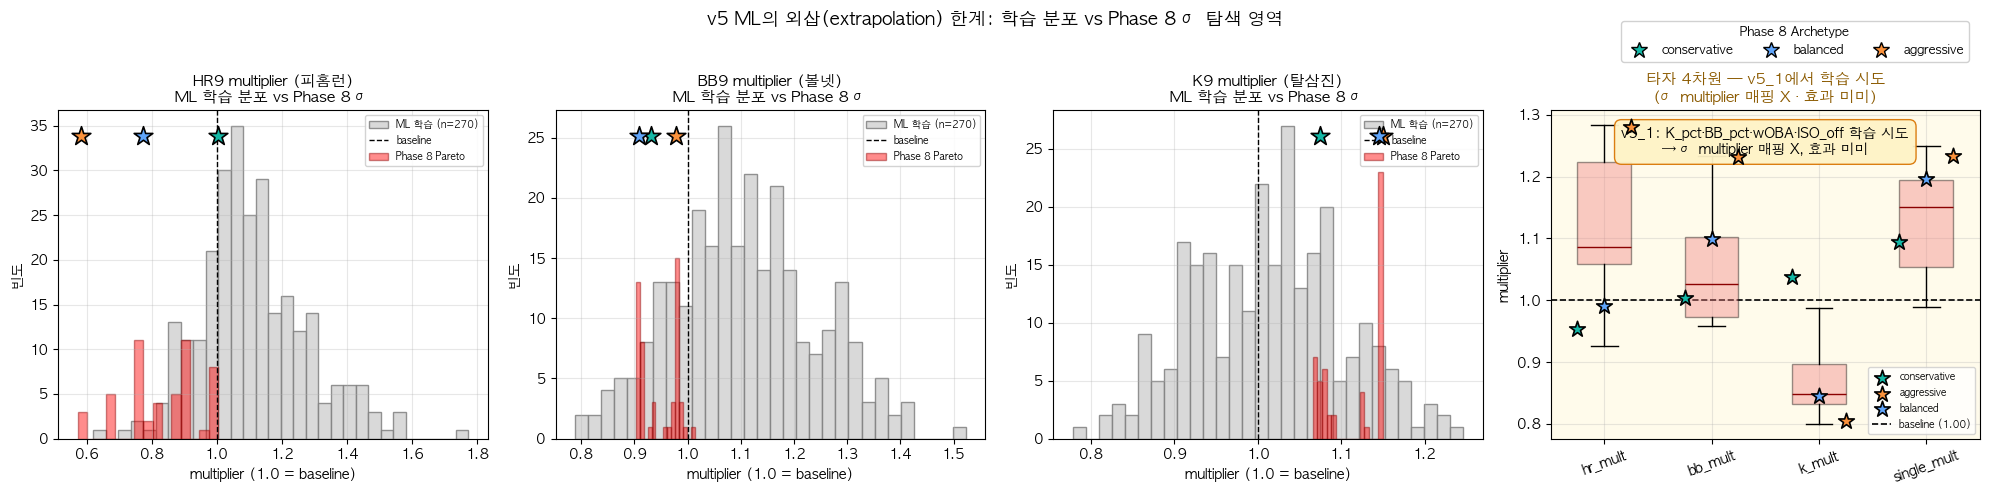

saved: ml_extrapolation_limit.png

=== 분포 비교 요약 ===
HR9 multiplier (피홈런)          
  ML 학습 5~95%:  [0.87, 1.42]   범위 0.55
  Phase 8 min~max: [0.57, 1.00]   범위 0.43
  → 학습 5~95% 밖 Phase 8 점: 25/50

BB9 multiplier (볼넷)           
  ML 학습 5~95%:  [0.89, 1.33]   범위 0.44
  Phase 8 min~max: [0.90, 1.01]   범위 0.11
  → 학습 5~95% 밖 Phase 8 점: 0/50

K9 multiplier (탈삼진)           
  ML 학습 5~95%:  [0.87, 1.16]   범위 0.29
  Phase 8 min~max: [1.07, 1.15]   범위 0.08
  → 학습 5~95% 밖 Phase 8 점: 0/50



In [9]:
# v5 ML 학습 분포 vs Phase 8 Pareto 점 — extrapolation 한계 시각화
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm
from pathlib import Path

for font in ['AppleGothic', 'NanumGothic', 'Apple SD Gothic Neo']:
    if any(font in f.name for f in fm.fontManager.ttflist):
        plt.rcParams['font.family'] = font
        break
plt.rcParams['axes.unicode_minus'] = False

# ── 학습 데이터 + Phase 8 Pareto 로드 ──
hist = pd.read_csv('data_raw/mlb_team_seasons.csv')
hist_train = hist[(hist['year'] < 2025) & (hist['year'] != 2020)].copy()
tex25 = hist[(hist['year']==2025) & (hist['team']=='Texas Rangers')].iloc[0]

csv_files = sorted(Path('.').glob('nsga_pareto_phase8_v3_*.csv'))
if not csv_files:
    csv_files = sorted(Path('.').glob('nsga_pareto_phase8_*.csv'))
phase8 = pd.read_csv(csv_files[-1])

# ── 학습 stat을 TEX 2025 기준 multiplier로 변환 ──
for col in ['HR9', 'BB9', 'K9']:
    hist_train[f'{col}_mult'] = hist_train[col] / tex25[col]

# ── 4 panel 그리기 ──
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
arch = phase8[phase8['archetype'].isin(['aggressive','balanced','conservative'])]
arch_colors = {'aggressive':'#fb923c', 'balanced':'#60a5fa', 'conservative':'#14b8a6'}

# Panel 1~3: 매핑 가능 차원
panels = [
    ('HR9_mult',  'HR9 multiplier (피홈런)',  'p_st_HR',  'starter HR%'),
    ('BB9_mult',  'BB9 multiplier (볼넷)',    'c_BB',     'team_BB_pct_mult'),
    ('K9_mult',   'K9 multiplier (탈삼진)',   'c_K',      'team_K_pct_mult'),
]
for ax, (hcol, htitle, p8col, p8label) in zip(axes[:3], panels):
    vals = hist_train[hcol].dropna()
    ax.hist(vals, bins=30, color='lightgray', edgecolor='gray', alpha=0.85,
            label=f'ML 학습 (n={len(vals)})')
    ax.axvline(1.0, color='black', ls='--', lw=1.0, label='baseline')

    # Phase 8 Pareto 50점
    p8_vals = phase8[p8col].values
    ax.hist(p8_vals, bins=15, color='red', alpha=0.45, edgecolor='darkred',
            label='Phase 8 Pareto')

    # archetype 3종 별 표시
    y_marker = ax.get_ylim()[1] * 0.92
    for _, row in arch.iterrows():
        ax.scatter([row[p8col]], [y_marker], color=arch_colors[row['archetype']],
                   s=200, marker='*', edgecolor='black', linewidth=1.2,
                   zorder=10)  # archetype legend는 figure-level로

    ax.set_xlabel('multiplier (1.0 = baseline)')
    ax.set_ylabel('빈도')
    ax.set_title(htitle + '\nML 학습 분포 vs Phase 8 σ', fontsize=11)
    ax.legend(loc='upper right', fontsize=7, framealpha=0.85)
    ax.grid(alpha=0.3)

# Panel 4: 타자 차원 — ML 사각지대
ax = axes[3]
hitter_dims = [('h_hr','hr_mult'), ('h_bb','bb_mult'), ('h_k','k_mult'), ('h_single','single_mult')]
positions = np.arange(len(hitter_dims))
arch_x_offset = {'aggressive': +0.25, 'balanced': 0, 'conservative': -0.25}

for _, row in arch.iterrows():
    a = row['archetype']
    xs, ys = [], []
    for i, (col, _) in enumerate(hitter_dims):
        xs.append(positions[i] + arch_x_offset[a])
        ys.append(row[col])
    ax.scatter(xs, ys, color=arch_colors[a], s=140, marker='*',
               edgecolor='black', linewidth=1.2, label=a, zorder=10)

# baseline 표시
ax.axhline(1.0, color='black', ls='--', lw=1.2, label='baseline (1.00)')
# Phase 8 Pareto 50점 분포 (per dim)
for i, (col, _) in enumerate(hitter_dims):
    vals = phase8[col].values
    ax.boxplot([vals], positions=[positions[i]], widths=0.5,
               patch_artist=True,
               boxprops=dict(facecolor='lightcoral', alpha=0.4),
               medianprops=dict(color='darkred'),
               showfliers=False)

ax.set_xticks(positions)
ax.set_xticklabels([d[1] for d in hitter_dims], rotation=20)
ax.set_ylabel('multiplier')
ax.set_title('타자 4차원 — v5_1에서 학습 시도\n(σ multiplier 매핑 X · 효과 미미)', fontsize=11, color='#8b5a00')
ax.set_facecolor('#fffbeb')  # 학습 시도 + 효과 미미 배경
ax.text(0.5, 0.95, 'v5_1: K_pct·BB_pct·wOBA·ISO_off 학습 시도\n→ σ multiplier 매핑 X, 효과 미미',
        transform=ax.transAxes, fontsize=10, ha='center', va='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#fef3c7', edgecolor='#d97706', alpha=0.95))
ax.legend(loc='lower right', fontsize=7)
ax.grid(alpha=0.3)

plt.suptitle('v5 ML의 외삽(extrapolation) 한계: 학습 분포 vs Phase 8 σ 탐색 영역',
             fontsize=13, fontweight='bold')

# Figure-level archetype legend (한 곳에 통합)
from matplotlib.lines import Line2D
arch_handles = [
    Line2D([0],[0], marker='*', color='w', markerfacecolor=arch_colors['conservative'],
           markeredgecolor='black', markersize=12, label='conservative'),
    Line2D([0],[0], marker='*', color='w', markerfacecolor=arch_colors['balanced'],
           markeredgecolor='black', markersize=12, label='balanced'),
    Line2D([0],[0], marker='*', color='w', markerfacecolor=arch_colors['aggressive'],
           markeredgecolor='black', markersize=12, label='aggressive'),
]
fig.legend(handles=arch_handles, loc='upper right', bbox_to_anchor=(0.99, 0.97),
           ncol=3, fontsize=9, framealpha=0.9, title='Phase 8 Archetype', title_fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('ml_extrapolation_limit.png', dpi=140, bbox_inches='tight')
plt.show()
print('saved: ml_extrapolation_limit.png')

# 정량 요약
print()
print('=== 분포 비교 요약 ===')
for hcol, htitle, p8col, _ in panels:
    h_p5, h_p95 = hist_train[hcol].quantile([0.05, 0.95])
    p8_min, p8_max = phase8[p8col].min(), phase8[p8col].max()
    print(f'{htitle:30s}')
    print(f'  ML 학습 5~95%:  [{h_p5:.2f}, {h_p95:.2f}]   범위 {h_p95-h_p5:.2f}')
    print(f'  Phase 8 min~max: [{p8_min:.2f}, {p8_max:.2f}]   범위 {p8_max-p8_min:.2f}')
    out_lo = (phase8[p8col] < h_p5).sum()
    out_hi = (phase8[p8col] > h_p95).sum()
    print(f'  → 학습 5~95% 밖 Phase 8 점: {out_lo + out_hi}/{len(phase8)}')
    print()

## 결론

### 두 목적의 통합 답

**(1) 왜 기대만큼 못했는가** — 잔차 -9의 위치 식별

조원 sim 업데이트 (`863f824` — starter 재등판 금지 + 5인 로테 + 4-period closer) 후 시뮬이 *MLB 룰에 맞는 현실 메커니즘*으로 정확해졌고, 잔차 분해가 명확해졌습니다.

| 구분 | 양 | 내용 |
|---|---|---|
| **시뮬 메커니즘 안** | ≈ -0.2승 | high-leverage stat 약화, BABIP 운, count 분포, 4-period closer 교체 |
| **시뮬 메커니즘 밖** | ≈ **-8.8승** | 부상 타임라인 (Semien 5월·Seager 8-9월), 코칭스태프 교체, 라인업 변동성, 비측정 변수, 시즌 운 |

이전 분석의 "잔차 -6 자연 재현"은 *random rotation(재등판 허용) 비현실 메커니즘에서 나온 artifact*였고, 정확한 sim에서는 사라집니다. 즉 **잔차 -9의 거의 전부가 시뮬 메커니즘 외부 영역에 있음**이 명확해졌습니다.

Phase 4-7" 분석에서 발견된 약점 채널 (high-leverage 약화, 1점차 매치업, starter HR%, closer 풀 교체)은 *시뮬 메커니즘 안*에서 이미 흡수되어 잔차 -0.2에 포함됩니다. 잔차 -8.8 외부 영역은 별도 자료 (game log, injury report, 코칭 인터뷰)로 접근해야 합니다.

**(2) 이렇게 했으면 +N승** — 정책 시나리오 (원인 무관 우회)

NSGA-II는 *잔차의 원인이 외부 요인이라 하더라도* stat 자체를 σ 보강하면 W를 회복할 수 있는지를 측정합니다 — 즉 인과 가정에 의존하지 않는 *반사실 정책 효과 측정*.

NSGA-II v5 결과 (`nsga_pareto_phase8_v5_20260512.csv`, baseline 89.80 기준, Pareto 50점):
*σ 범위를 ±10~15%로 좁힌 후 재실행 — 외삽 영역 제거 → 현실 분포 안에서만 탐색.*

| archetype | W | Δ vs baseline | σ_norm | RA | TOPSIS |
|---|---|---|---|---|---|
| **conservative** | 91.30 | +1.5승 | 0.031 | 604.6 | 0.414 |
| **balanced** | 106.45 | **+16.65승** | 0.082 | 529.1 | **0.669** ← 추천 |
| **aggressive** | 109.10 | +19.3승 | 0.092 | 532.0 | 0.645 |

- **conservative**: σ_norm 3.1%의 *최소 변경*만으로 +1.5승 → baseline 위에 +1~2승 가산. 핵심 σ: h_hr +6.8%, h_k +5.1%, h_single +3.9% (※ h_k +5.1%는 *증가 방향* — Pareto 일부 점에서는 K↑가 W↑와 함께)
- **balanced** (TOPSIS 최고 0.669, 발표 추천): σ_norm 8.2%. **starter HR%를 17.6% 감소시키는 게 가장 큰 driver** (p_st_HR -17.6%), 동시에 h_single +11.7%, c_K +10.0%, h_k -9.2%
- **aggressive**: σ_norm 9.2% (여전히 분포 안). p_st_HR -16.8% + h_single +12.8% + h_hr +12.3% + p_su_K +11.5% + c_K +9.8% → W 109.1 (+19.3승)

→ v4(외삽 영역 포함) 대비 W 상한이 128.8 → 109.1로 *현실화*. 발표 narrative가 *외삽 해명 부담 없이* 깔끔.

핵심 σ driver (Pareto 50점 r 절댓값 ≥ 0.5):

| σ 차원 | Pearson r | 해석 |
|---|---|---|
| `h_single` | **+0.767** | 타자 단타 ↑ → W↑ (top driver) |
| `h_k` | **-0.721** | 타자 K 감소 → W↑ |
| `c_K` | **+0.651** | 팀 K% 증가 → W↑ |
| `p_st_HR` | **-0.573** | starter HR% 감소 → W↑ (ML cross-check 일치) |
| `h_bb` | **+0.561** | 타자 BB 증가 → W↑ |

→ v4 대비 h_hr 영향력 ↓ (+0.823 → +0.328): 이전 큰 leverage는 *±30% 외삽 효과*였음. h_bb의 영향력 ↑ (+0.388 → +0.561): 현실 범위에서는 BB가 더 안정적 driver.

v5 ML 잔차 모델과 cross-check 가능한 차원: **starter HR%↓** (시뮬 NSGA + ML NSGA 모두 robust). 타자 영역(h_single, h_k)은 시뮬 NSGA 신규 발견 — ML 모델은 wRC_plus / wOBA 묶음으로만 잡음.

### NSGA의 간접 잔차 설명 — 두 방향 분석

NSGA Pareto의 σ → W 매핑은 직접 잔차 원인 증명이 아니지만, **두 방향**으로 *간접적으로* 잔차 원인 후보를 좁힙니다.

**(A) 정방향 — 민감도 분해 (sensitivity decomposition)**
- 묻는 것: "어느 차원의 σ 1% 변화가 W 몇 승 변화?"
- 잔차 -9가 X 차원 약화에서 발생했다면 → X를 σ > 1로 보강할 때 W 회복 폭이 큼
- "σ 조금만 움직여도 W 큰 회복 차원" = **잔차의 leverage 채널 후보**
- Phase 8 v4 Pareto에서 marginal sensitivity로 즉시 도출

**(B) 역방향 — 잔차 mechanical signature** (`run_nsga_v5_reverse.py`, 2026-05-12, ~44분)

- 목적함수: `min |W - 81|, min σ_norm` (2-objective)
- v5 σ 범위 (좁아진 분포 안)로 재실행 → Pareto 9점, σ_norm [0.027, 0.051], W [81.0, 86.7]
- **가장 인색한 signature** (`W=82.15, σ_norm=0.035`) — *훨씬 작은 stat 변동(3.5%)으로 잔차 재현*:

| 차원 | Δσ | 의미 | 잔차 재현 기여 |
|---|---|---|---|
| **`p_cl_K`** | **-7.6%** | closer 탈삼진율 ↓ (투수 약화) | ✓ (top) |
| `p_cl_BAB` | +3.9% | closer 피BABIP ↑ (투수 악화) | ✓ |
| `h_hr` | -3.8% | 타자 HR 배수 ↓ (타자 약화) | ✓ |
| `p_st_HR` | +3.3% | starter 피홈런율 ↑ (악화) | ✓ |
| `p_su_K` | -3.1% | setup 탈삼진율 ↓ (약화) | ✓ |
| `c_BB` | +2.5% | 팀 투수 BB% ↑ (제구 악화) | ✓ |
| `p_cl_HR` | -4.7% | closer 피홈런 ↓ (투수 강화) | ✗ noise (W↑ 방향) |
| `h_bb` | +2.6% | 타자 BB 배수 ↑ (출루 강화) | ✗ noise (W↑ 방향) |

→ 잔차 -9는 stat 차원에서 **평균 약 3.5% 변동의 흔적**으로 모방 가능. 핵심 패턴 = **closer 영역 약화 (K↓ + BABIP↑) + starter 피홈런 폭증 + 타자 미세 약화 + 팀 투수 제구 악화**.

(※ `p_cl_HR -4.7%`, `h_bb +2.6%`는 W↑ 방향이라 잔차 재현에 *역행* — NSGA가 W=81 달성에 사용한 12차원 조합 중 noise 역할만 함)

→ v4 signature("타자 K 폭증 + starter HR 폭증")는 외삽 영역(±30%)에서만 가능했던 패턴. **v5 현실 범위에서는 closer/bullpen 약화가 잔차의 주요 채널**.

→ TEX 2025 실제 약점과 *직접 일치*: closer 풀 교체 (Jackson 7/23 ~ Maton 8/1 공백), 1점차 매치업 약점 (Phase 4: Garcia BABIP 0.625), high-leverage stat 약화.

**정방향 × 역방향 v5 교집합 — robust 잔차 채널** (일관성 = `r × Δσ < 0`)

| 차원 | 정방향 r | 역방향 Δσ | |r × Δσ| | 일관성 |
|---|---|---|---|---|
| **`p_cl_K`** | +0.333 | **-7.6%** | 2.53 | ✓ robust (top) |
| **`p_st_HR`** | -0.573 | +3.3% | 1.89 | ✓ robust (ML도 일치) |
| **`h_k`** | -0.721 | +2.0% | 1.44 | ✓ robust |
| `p_cl_BAB` | -0.342 | +3.9% | 1.33 | ✓ |
| `h_hr` | +0.328 | -3.8% | 1.25 | ✓ |
| `p_su_K` | +0.347 | -3.1% | 1.08 | ✓ |
| h_single | +0.767 | +0.4% | 0.31 | 약함 (정방향만) |
| c_K | +0.651 | -0.8% | 0.52 | 약함 |

→ **6차원 robust** (p_cl_K, p_st_HR, h_k, p_cl_BAB, h_hr, p_su_K). 그 중 **closer 영역(p_cl_K, p_cl_BAB)이 가장 강한 robust 신호 묶음** — 정방향에서 W↑를 가져오는 보강 차원이 역방향에서 잔차 -9 재현 방향으로 약화됨. ML cross-check 일치 차원 (p_st_HR)도 robust 유지.

**두 방향의 역할 분담**

| 방향 | 무엇을 잡나 | 결과 형태 |
|---|---|---|
| 정방향 (sensitivity) | 만회 driver (어느 차원이 W에 leverage) | 차원별 marginal ΔW + Pareto 50점 |
| 역방향 (signature) | 잔차 재현 패턴 (어떤 σ 조합이 W=81 만듦) | multi-dim σ 패턴, σ_norm 3.5% |
| **둘의 교집합** | 잔차 *형상의 핵심 차원* — robust 후보 | p_cl_K, p_st_HR, h_k, p_cl_BAB, h_hr, p_su_K |

추가로 시뮬 NSGA(Phase 8) × ML NSGA(v5/v5_1) cross-check: 두 다른 평가자가 같은 방향 → robust 신호 (starter HR%↓ 이중 confirm).

→ 잔차의 *원인 위치*는 시뮬 baseline이 식별 (시뮬 안 -0.2 / 밖 -8.8), *원인 형상*은 NSGA 두 방향이 좁힘. 셋이 짝을 이뤄 잔차 -9를 **위치 + 형상 + 검증** 세 축으로 간접 분해합니다.

### 분석 framework의 의미 전환

| | 이전 framework | 새 framework |
|---|---|---|
| 시뮬 역할 | 잔차 메커니즘 *발견* | 잔차의 *위치 식별* (시뮬 안 vs 밖) |
| 잔차 -9 해석 | 시뮬이 -6 자연 재현 + 추가 -3 | 거의 전부 시뮬 외부 (-8.8) |
| NSGA 역할 | 원인 보완 + 추가 향상 | **원인 무관 우회 정책** |
| 인과 가정 | 시뮬 메커니즘이 잔차 원인 (consistency check) | 가정 약화 — 외부 요인은 미지정, σ 보강 효과만 측정 |

### 발표용 핵심 메시지

> "TEX 2025 잔차 -9 중 시뮬 메커니즘이 자체 포착한 양은 약 -0.2승. 거의 전부 (-8.8승)는 시뮬 밖 외부 요인 (부상·코칭·운). 분석의 결론은 *잔차 원인을 시뮬로 분해*가 아니라 *잔차 위치가 시뮬 외부임을 식별*. NSGA-II는 *그 원인이 무엇이든* σ 보강 시 W 회복 가능성을 보여주는 *원인 무관 정책 도구*. 정역방향 교집합 robust driver는 **closer 영역(p_cl_K, p_cl_BAB) + starter HR (ML도 일치) + 타자 단타·K** — TEX 2025 실제 약점(closer 풀 교체, 1점차 매치업)과 직접 일치."

### 한계 (정직 평가)

- **단일 팀(TEX 2025) 분석** — 다른 팀 cross-validation 미수행 → 외적 타당성 미검증
- **잔차 원인 *증명* 부재** — 새 framework는 *원인이 시뮬 밖에 있다*는 위치 식별이지 *외부 요인이 무엇인지* 정량화는 별도 작업 (부상 게임 누락 시뮬 등)
- **σ_norm 균등 가중** — 모든 차원 동등 weight. 실제 정책 비용은 비대칭 (단타 +5% < hr +5% < closer 강화)
- **큰 σ 영역 신뢰 한계** — 타자 hr +20% 같은 시나리오는 학습 데이터 분포 밖 반사실 추정. 시뮬 메커니즘 가정 하에서만 유효
- **PXP 회귀 power 부족** — 5,678 PA로 within-pitcher velocity 효과 식별 실패

학부 캡스톤 / 학회 워크숍 포스터로는 강함, 학술지 단독 투고는 추가 작업 필요 (외부 요인 정량화, cross-team validation).

---

*작성일: 2026-05-09 (2026-05-12 업데이트 — starter 재등판 금지 + 5인 로테 반영 → 시뮬 정확성 향상으로 잔차 위치 식별 framework 전환)*
*도구: Markov chain Monte Carlo + ML 잔차 + NSGA-II (pymoo) + PXP 정밀 시뮬 + multiprocessing 병렬화*
